# Helpers

In [ ]:
def warp_raster_to_template(src_path, template_path, out_path, resampling, dst_nodata=-9999.0):
    with rio.open(template_path) as tmpl, rio.open(src_path) as src:
        dst_meta = src.meta.copy()
        dst_meta.update(
            driver="GTiff",
            crs=tmpl.crs,
            transform=tmpl.transform,
            width=tmpl.width,
            height=tmpl.height,
            nodata=dst_nodata,
            compress="deflate",
            tiled=True,
            BIGTIFF="YES",
            blockxsize=256,
            blockysize=256,
        )
        with rio.open(out_path, "w", **dst_meta) as dst:
            for b in range(1, src.count + 1):
                reproject(
                    source=rio.band(src, b),
                    destination=rio.band(dst, b),
                    src_transform=src.transform,
                    src_crs=src.crs,
                    src_nodata=src.nodata,
                    dst_transform=tmpl.transform,
                    dst_crs=tmpl.crs,
                    dst_nodata=dst_nodata,
                    resampling=resampling,
                )
    return out_path

def clean_continuous(a, nodata, fill=0.0):
    a = a.astype("float32", copy=False)
    a = np.nan_to_num(a, nan=fill, posinf=fill, neginf=fill)
    if nodata is not None:
        a = np.where(a == nodata, fill, a)
    return a

import arcpy

def ensure_field(dataset, name, ftype, length=None):
    """Add a field if it doesn't already exist."""
    existing = {f.name for f in arcpy.ListFields(dataset)}
    if name not in existing:
        if ftype.upper() == "TEXT" and length is not None:
            arcpy.management.AddField(dataset, name, ftype, field_length=length)
        else:
            arcpy.management.AddField(dataset, name, ftype)


# Stich Great Lake DEM

In [ ]:
import os, glob
import rasterio
from rasterio.merge import merge
from rasterio.warp import calculate_default_transform, reproject, Resampling

Modeltop = r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\DEM"
target_crs = "EPSG:3174"
target_res = 30
nodata_out = -9999.0

tmp_dir = os.path.join(Modeltop, "_tmp_reproj_3174")
os.makedirs(tmp_dir, exist_ok=True)

tifs = sorted(glob.glob(os.path.join(Modeltop, "*.tif")))
if not tifs:
    raise FileNotFoundError(f"No .tif files found in: {Modeltop}")

reproj_paths = []

for fp in tifs:
    with rasterio.open(fp) as src:
        if src.crs is None:
            raise ValueError(f"{os.path.basename(fp)} has no CRS. Define Projection first.")

        src_nodata = src.nodata
        out_fp = os.path.join(tmp_dir, os.path.splitext(os.path.basename(fp))[0] + "_3174.tif")

        if not os.path.exists(out_fp):
            transform, width, height = calculate_default_transform(
                src.crs, target_crs, src.width, src.height, *src.bounds
            )

            meta = src.meta.copy()
            meta.update({
                "crs": target_crs,
                "transform": transform,
                "width": width,
                "height": height,
                "dtype": "float32",
                "nodata": nodata_out,
                "compress": "lzw",
                "tiled": True,
                "BIGTIFF": "IF_SAFER"
            })

            with rasterio.open(out_fp, "w", **meta) as dst:
                reproject(
                    source=rasterio.band(src, 1),
                    destination=rasterio.band(dst, 1),
                    src_transform=src.transform,
                    src_crs=src.crs,
                    src_nodata=src_nodata,
                    dst_transform=transform,
                    dst_crs=target_crs,
                    dst_nodata=nodata_out,
                    resampling=Resampling.bilinear
                )

        reproj_paths.append(out_fp)

# Merge and write directly to disk (BigTIFF)
out_tif = os.path.join(Modeltop, "DEM_merged_3174_30m.tif")

srcs = [rasterio.open(fp) for fp in reproj_paths]
template = srcs[0].meta.copy()
template.update({
    "driver": "GTiff",
    "crs": target_crs,
    "dtype": "float32",
    "nodata": nodata_out,
    "compress": "lzw",
    "tiled": True,
    "BIGTIFF": "YES"
})

merge(
    srcs,
    res=(target_res, target_res),
    nodata=nodata_out,
    resampling=Resampling.bilinear,
    target_aligned_pixels=True,
    dst_path=out_tif,
    dst_kwds=template
)

for s in srcs:
    s.close()

print("✅ Wrote:", out_tif)


In [ ]:
import arcpy
arcpy.env.overwriteOutput = True

out_tif = r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\DEM\DEM_merged_3174_30m.tif"

arcpy.management.CalculateStatistics(out_tif)
arcpy.management.BuildPyramids(out_tif)
print("✅ Built statistics + pyramids")

# Stich the Lakes

In [ ]:
out_dir  = r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers"


In [ ]:
import os
import arcpy

Lakes_path = r"D:\Users\abolmaal\Arcgis\GreatLakes"
out_shp = os.path.join(Lakes_path, "hydro_p_GreatLakes.shp")

arcpy.env.workspace = Lakes_path
arcpy.env.overwriteOutput = True

# Get all shapefiles in the folder
shps = arcpy.ListFeatureClasses(feature_type="All")
shps = [os.path.join(Lakes_path, s) for s in shps if s.lower().endswith(".shp")]

if not shps:
    raise FileNotFoundError(f"No shapefiles found in: {Lakes_path}")

# Merge
arcpy.management.Merge(shps, out_shp)

print(f"✅ Merged {len(shps)} shapefiles -> {out_shp}")


# Create constant heads boundary 


to make a constant-head (CHD) boundary from your basin DEM, you basically do two things:

1- decide which grid cells are “constant head” (usually the Great Lakes water cells, and sometimes the outer model boundary), and

2- assign a head value (stage elevation) to those cells for each stress period.

### 1) Rasterize your hydro polygons to your 30 m model grid (aligned to your DEM)

This makes a water_30m.tif where water cell = -1, outside = 0, inside (land) = 1

In [13]:
import os
import arcpy
from arcpy import sa

arcpy.CheckOutExtension("Spatial")
arcpy.env.overwriteOutput = True

# ----------------------------
# INPUTS
# ----------------------------
hydro_p = r"D:\Users\abolmaal\Arcgis\GreatLakes\hydro_p_GreatLakes.shp"
dem = r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\DEM\DEM_merged_3174_30m.tif"
boundary_p = r"S:\Projects\Active\GLB_LHM\LHM_inputs\Boundary\extendedBdry_jan26_adk.shp"

out_dir = r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\Costantheads"
os.makedirs(out_dir, exist_ok=True)

buffer_dist_m = 20000  # 20 km buffer

# ----------------------------
# ENV ALIGNMENT
# ----------------------------
arcpy.env.snapRaster = dem
arcpy.env.cellSize   = dem
arcpy.env.extent     = dem
arcpy.env.outputCoordinateSystem = arcpy.Describe(dem).spatialReference

dem_r  = arcpy.Raster(dem)
dem_sr = arcpy.Describe(dem).spatialReference

print("DEM rows/cols:", dem_r.height, dem_r.width)
print("DEM cellsize:", dem_r.meanCellWidth, dem_r.meanCellHeight)
print("DEM SR:", dem_sr.name, "factoryCode:", dem_sr.factoryCode)

# ----------------------------
# HELPERS
# ----------------------------
def safe_delete(path):
    if arcpy.Exists(path):
        arcpy.management.Delete(path)

def project_if_needed(fc, out_name):
    sr = arcpy.Describe(fc).spatialReference
    if sr.factoryCode != dem_sr.factoryCode:
        out_fc = os.path.join(out_dir, out_name)
        safe_delete(out_fc)
        arcpy.management.Project(fc, out_fc, dem_sr)
        return out_fc
    return fc

def ensure_constant_field(fc, field_name, value=1):
    fset = {f.name.upper() for f in arcpy.ListFields(fc)}
    if field_name.upper() not in fset:
        arcpy.management.AddField(fc, field_name, "SHORT")
    arcpy.management.CalculateField(fc, field_name, str(value), "PYTHON3")
    return field_name

# ----------------------------
# PROJECT INPUTS
# ----------------------------
hydro_use = project_if_needed(hydro_p, "hydro_proj.shp")
bnd_use   = project_if_needed(boundary_p, "boundary_proj.shp")

# ----------------------------
# FIX GEOMETRY (optional but helps with weird gaps)
# ----------------------------
try:
    arcpy.management.RepairGeometry(bnd_use)
except Exception as e:
    print("⚠️ RepairGeometry skipped/failed:", e)

# ----------------------------
# 2 KM BUFFER AROUND BOUNDARY
# ----------------------------
bnd_buff = os.path.join(out_dir, f"boundary_buffer_{buffer_dist_m}m.shp")
safe_delete(bnd_buff)

# dissolve_option="ALL" prevents internal seams
arcpy.analysis.Buffer(
    in_features=bnd_use,
    out_feature_class=bnd_buff,
    buffer_distance_or_field=f"{buffer_dist_m} Meters",
    dissolve_option="ALL"
)

print("✅ Buffered boundary saved:", bnd_buff)

# ----------------------------
# RASTERIZE BUFFERED BOUNDARY: inside=1, outside=0
# ----------------------------
bnd_field = ensure_constant_field(bnd_buff, "BNDVAL", 1)

bnd_raw = os.path.join(out_dir, "boundary_buff_raw.tif")
safe_delete(bnd_raw)

arcpy.conversion.PolygonToRaster(
    in_features=bnd_buff,
    value_field=bnd_field,
    out_rasterdataset=bnd_raw,
    cell_assignment="MAXIMUM_AREA",
    priority_field="NONE",
    cellsize=dem
)

bnd_ras = sa.Int(sa.Con(sa.IsNull(bnd_raw), 0, 1))  # 0/1 everywhere

# ----------------------------
# RASTERIZE WATER: water=1, else 0
# ----------------------------
wat_field = ensure_constant_field(hydro_use, "WATVAL", 1)

wat_raw = os.path.join(out_dir, "water_raw.tif")
safe_delete(wat_raw)

arcpy.conversion.PolygonToRaster(
    in_features=hydro_use,
    value_field=wat_field,
    out_rasterdataset=wat_raw,
    cell_assignment="MAXIMUM_AREA",
    priority_field="NONE",
    cellsize=dem
)

water_ras = sa.Int(sa.Con(sa.IsNull(wat_raw), 0, 1))

# ----------------------------
# FINAL MASK:
# outside buffered boundary = 0
# inside buffered boundary (non-water) = 1
# water = -1  (only within buffered boundary)
# ----------------------------
base  = bnd_ras
final = sa.Con(water_ras == 1, -1, base)
final = sa.Con(bnd_ras == 0, 0, final)   # enforce outside=0
final = sa.Int(final)

# ----------------------------
# SAVE TO FILE GEODATABASE
# ----------------------------
gdb = os.path.join(out_dir, "rasters.gdb")
if not arcpy.Exists(gdb):
    arcpy.management.CreateFileGDB(out_dir, "rasters.gdb")

out_gdb_ras = os.path.join(gdb, f"domain_water_mask_30m_buff{buffer_dist_m}m")
safe_delete(out_gdb_ras)

arcpy.management.CopyRaster(
    in_raster=final,
    out_rasterdataset=out_gdb_ras,
    pixel_type="16_BIT_SIGNED",
    nodata_value="0"
)

print("✅ Saved to GDB raster:", out_gdb_ras)

# ----------------------------
# OPTIONAL: export to TIFF (may fail if huge)
# ----------------------------
out_tif = os.path.join(out_dir, f"domain_water_mask_30m_buff{buffer_dist_m}m.tif")
safe_delete(out_tif)

try:
    arcpy.management.CopyRaster(
        in_raster=out_gdb_ras,
        out_rasterdataset=out_tif,
        pixel_type="16_BIT_SIGNED",
        nodata_value="0",
        format="TIFF"
    )
    print("✅ Exported TIFF:", out_tif)
except Exception as e:
    print("⚠️ TIFF export failed (likely too large). Keep the GDB raster.")
    print("   Error:", e)

# ----------------------------
# SMALL SAMPLE CHECK
# ----------------------------
import numpy as np
sample = arcpy.RasterToNumPyArray(out_gdb_ras, ncols=500, nrows=500, nodata_to_value=999)
vals = np.unique(sample[sample != 999])
print("✅ sample unique values:", vals)


DEM rows/cols: 49758 66126
DEM cellsize: 30.0 30.0
DEM SR: NAD_1983_Great_Lakes_Basin_Albers factoryCode: 3174
✅ Buffered boundary saved: D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\Costantheads\boundary_buffer_20000m.shp
✅ Saved to GDB raster: D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\Costantheads\rasters.gdb\domain_water_mask_30m_buff20000m
✅ Exported TIFF: D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\Costantheads\domain_water_mask_30m_buff20000m.tif
✅ sample unique values: []


In [14]:
## Step A — Create a “shoreline ring” raster (land cells adjacent to lake)
import arcpy
import numpy as np
from arcpy.sa import Raster, Con, FocalStatistics, NbrRectangle

arcpy.CheckOutExtension("Spatial")
arcpy.env.overwriteOutput = True

mask = r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\Costantheads\domain_water_mask_30m_buff20000m.tif"  # your output
out_ring = r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\Costantheads\chd_shore_ring.tif"

r = Raster(mask)
lake = Con(r == -1, 1)             # 1 on lakes, NoData elsewhere
land = Con(r == 1, 1)              # 1 on land, NoData elsewhere

# Any land cell with a lake neighbor in a 3x3 window
lake_near = FocalStatistics(lake, NbrRectangle(3,3,"CELL"), "MAXIMUM", "DATA")
ring = Con((land == 1) & (lake_near == 1), 1, 0)

ring.save(out_ring)
print("✅ CHD shoreline ring raster:", out_ring)

✅ CHD shoreline ring raster: D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\Costantheads\chd_shore_ring.tif


In [21]:
# Step B — Convert ring raster to points (CHD cell centers)

out_pts = r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\Costantheads\CHD_cells_points.shp"

if arcpy.Exists(out_pts):
    arcpy.management.Delete(out_pts)

arcpy.conversion.RasterToPoint(out_ring, out_pts, "Value")
print("✅ CHD points:", out_pts)

✅ CHD points: D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\Costantheads\CHD_cells_points.shp


In [22]:
# Step C — Assign head values (better than constant 175)
# Simple + safe: head = min(lake_stage, DEM - 0.5)
import arcpy
from arcpy.sa import ExtractValuesToPoints

arcpy.CheckOutExtension("Spatial")
arcpy.env.overwriteOutput = True

out_pts = r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\Costantheads\CHD_cells_points.shp"
dem     = r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\DEM\DEM_merged_3174_30m.tif"

# IMPORTANT: output must be a NEW file (not the same as out_pts)
out_pts_dem = r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\Costantheads\CHD_cells_points_dem.shp"

if arcpy.Exists(out_pts_dem):
    arcpy.management.Delete(out_pts_dem)

# optional but helpful
arcpy.management.RepairGeometry(out_pts)

# Extract DEM values to NEW points shapefile
ExtractValuesToPoints(out_pts, dem, out_pts_dem, interpolate_values="NONE")

print("✅ Wrote:", out_pts_dem)
print("Point count:", arcpy.management.GetCount(out_pts_dem)[0])
print("Fields:", [f.name for f in arcpy.ListFields(out_pts_dem)])

✅ Wrote: D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\Costantheads\CHD_cells_points_dem.shp
Point count: 482033
Fields: ['FID', 'Shape', 'pointid', 'grid_code', 'RASTERVALU']


In [24]:
# Assign head values based on DEM + lake stage
import arcpy

arcpy.env.overwriteOutput = True

pts_dem = r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\Costantheads\CHD_cells_points_dem.shp"

LAKE_STAGE = 177.0   # <-- choose your constant lake stage (m)
FREEBOARD  = 0.5     # head will be at least 0.5 m below DEM on land cells

# Add head field if missing
fields = [f.name for f in arcpy.ListFields(pts_dem)]
if "head" not in fields:
    arcpy.management.AddField(pts_dem, "head", "DOUBLE")

# Compute head from DEM sample (RASTERVALU)
with arcpy.da.UpdateCursor(pts_dem, ["RASTERVALU", "head"]) as cur:
    for dem_z, head in cur:
        if dem_z is None:
            new_head = LAKE_STAGE
        else:
            new_head = min(LAKE_STAGE, float(dem_z) - FREEBOARD)
        cur.updateRow((dem_z, new_head))

print("✅ head assigned to:", pts_dem)

# Quick sanity check (sample stats)
vals = []
with arcpy.da.SearchCursor(pts_dem, ["head"]) as cur:
    for (h,) in cur:
        if h is not None:
            vals.append(h)
        if len(vals) >= 200000:  # sample for speed
            break

print("Sample head min/max:", min(vals), max(vals))

✅ head assigned to: D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\Costantheads\CHD_cells_points_dem.shp
Sample head min/max: -9999.5 177.0


In [25]:
# raterize the head points back to raster (for visual check, not required for Modflow) and make sure the crs adn resolution match the model grid (template raster)

import os
import arcpy

arcpy.env.overwriteOutput = True

# Inputs
pts_dem = r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\Costantheads\CHD_cells_points_dem.shp"
template_raster = r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\GRID_3174\template_1000m_epsg3174.tif"

out_dir = r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\Costantheads"
os.makedirs(out_dir, exist_ok=True)

# Output raster (1000 m)
chd_head_ras = os.path.join(out_dir, "CHD_head_1000m.tif")

# --- CRS-safe: project points to template CRS if needed ---
sr_t = arcpy.Describe(template_raster).spatialReference
sr_p = arcpy.Describe(pts_dem).spatialReference

pts_use = pts_dem
if sr_p.factoryCode != sr_t.factoryCode:
    pts_proj = os.path.join(out_dir, "CHD_cells_points_dem_proj.shp")
    if arcpy.Exists(pts_proj):
        arcpy.management.Delete(pts_proj)
    arcpy.management.Project(pts_dem, pts_proj, sr_t)
    pts_use = pts_proj
    print("✅ Projected points to template CRS:", sr_t.factoryCode)

# Align output to model grid
arcpy.env.snapRaster = template_raster
arcpy.env.cellSize   = template_raster
arcpy.env.extent     = template_raster
arcpy.env.outputCoordinateSystem = sr_t

# Rasterize: MEAN head for each 1000m cell that has any points
if arcpy.Exists(chd_head_ras):
    arcpy.management.Delete(chd_head_ras)

arcpy.conversion.PointToRaster(
    in_features=pts_use,
    value_field="head",
    out_rasterdataset=chd_head_ras,
    cell_assignment="MEAN",
    priority_field="NONE",
    cellsize=arcpy.env.cellSize
)

arcpy.management.CalculateStatistics(chd_head_ras)
print("✅ CHD head raster:", chd_head_ras)

✅ CHD head raster: D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\Costantheads\CHD_head_1000m.tif


# Great Lakes MODFLOW 6: Hydraulic Conductivity (HK) Preparation


**Purpose:** 
This notebook automates the end-to-end creation of a 5-layer Hydraulic Conductivity (HK) multiband raster for MODFLOW 6.
It performs the following steps sequence:
1. Imports and pairs Quaternary surface geology with calibrated $K_h$ values from a CSV.
2. Converts units from $m/s$ to $m/day$.
3. Creates persistent domains for 5 strata layers (Upper, Middle, Lower, Fractured Bedrock, Deep Bedrock).
4. Masks out Lakes and assigns them a high conductivity ($100 \text{ m/day}$) to support Constant Head (CHD) boundaries.
5. Rasterizes the polygon to a 5-Band GeoTIFF snapped perfectly to the MODFLOW grid.


In [2]:
import os
import arcpy
from arcpy.sa import Raster, SetNull

# Ensure Spatial Analyst is available and outputs can be overwritten
arcpy.CheckOutExtension("Spatial")
arcpy.env.overwriteOutput = True

print("Libraries loaded. Environment set.")

## 1. Define File Paths and Constants
#Here we define the locations of the raw shapefiles, the CSV containing the parameters, the target template grid, and our conductivity constants.

# ============================================================
# INPUTS
# ============================================================
surfacegeology = r"S:\Data\Other_Data\Xu_2021\Data\09_Integrated_Surficial_Geology_Map\Integrated_surficial_geology_mapping.shp"
csv_path = r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\HK\Calibrated_surficial_Kh__ALLCOLS.csv"
extended_Buffer2km = r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\Costantheads\boundary_buffer_2000m.shp"
water_mask_raster = r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\Costantheads\domain_water_mask_30m_buff20000m.tif"
template_raster = r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\GRID_3174\template_1000m_epsg3174.tif"

# OUTPUT DIRECTORY
out_dir = r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\HK"
os.makedirs(out_dir, exist_ok=True)
gdb = os.path.join(out_dir, "HK_join_clip.gdb")
if not arcpy.Exists(gdb):
    arcpy.management.CreateFileGDB(out_dir, os.path.basename(gdb))

# ============================================================
# CONSTANTS & VALUES
# ============================================================
SEC_PER_DAY = 86400.0
LAKE_RASTER_VALUE = -1

# Kh Values (m/s)
LOWER_DEFAULT_MS = 1e-7      
FRAC_BEDROCK_MS  = 1e-6
BEDROCK_MS       = 1e-10

# Kh Values (m/day)
FRAC_BEDROCK_MDAY = FRAC_BEDROCK_MS * SEC_PER_DAY
BEDROCK_MDAY      = BEDROCK_MS * SEC_PER_DAY

# Values to burn into Lake / Land cells
LAKE_VALUE = 100.0
LAND_VALUE = 0.0

print("Paths and Constants Defined.")


Libraries loaded. Environment set.
Paths and Constants Defined.


## 2. Helper Functions
These functions help delete temporary files safely, ensure fields exist to prevent Arcpy errors, and create robust Text Join IDs so the CSV to Shapefile join never fails due to Type Mismatches.


In [3]:
def delete_if_exists(p):
    if p and arcpy.Exists(p):
        arcpy.management.Delete(p)

def ensure_field(dataset, name, ftype, length=None):
    existing = {f.name for f in arcpy.ListFields(dataset)}
    if name not in existing:
        if ftype.upper() == "TEXT" and length is not None:
            arcpy.management.AddField(dataset, name, ftype, field_length=length)
        else:
            arcpy.management.AddField(dataset, name, ftype)

def make_join_id(dataset, source_field, join_field="JOIN_ID"):
    ensure_field(dataset, join_field, "TEXT", length=50)
    codeblock = """def to_key(v):
    if v is None: return None
    s = str(v).strip()
    if s == "": return None
    try:
        fv = float(s)
        if fv.is_integer(): s = str(int(fv))
        else: s = str(fv)
    except: pass
    return s.strip().upper()"""
    arcpy.management.CalculateField(dataset, join_field, f"to_key(!{source_field}!)", "PYTHON3", code_block=codeblock)
    
def safe_clip(in_fc, clip_fc, out_fc):
    delete_if_exists(out_fc)
    if hasattr(arcpy.analysis, "PairwiseClip"): arcpy.analysis.PairwiseClip(in_fc, clip_fc, out_fc)
    else: arcpy.analysis.Clip(in_fc, clip_fc, out_fc)

def safe_erase(in_fc, erase_fc, out_fc):
    delete_if_exists(out_fc)
    if hasattr(arcpy.analysis, "PairwiseErase"): arcpy.analysis.PairwiseErase(in_fc, erase_fc, out_fc)
    else: arcpy.analysis.Erase(in_fc, erase_fc, out_fc)


## 3. Push to Geodatabase and Join CSV
Here we import the Geology Shapefile and the CSV into our File Geodatabase. We then join the properties together.


In [5]:
surf_fc = os.path.join(gdb, "surfacegeology_base")
csv_tbl = os.path.join(gdb, "Kh_csv_tbl")
joined_fc = os.path.join(gdb, "surfacegeo_joined")

print("Copying Geology to GDB...")
delete_if_exists(surf_fc)
arcpy.management.CopyFeatures(surfacegeology, surf_fc)

print("Importing CSV to GDB...")
delete_if_exists(csv_tbl)
arcpy.conversion.TableToTable(csv_path, gdb, "Kh_csv_tbl")

tbl_fields = [f.name for f in arcpy.ListFields(csv_tbl)]
if "Lower_ms" not in tbl_fields:
    ensure_field(csv_tbl, "Lower_ms", "DOUBLE")
    arcpy.management.CalculateField(csv_tbl, "Lower_ms", str(LOWER_DEFAULT_MS), "PYTHON3")

print("Processing Join Keys...")
# Note: Ensure that "col_1" is your actual ID field in the CSV matching "POLYID"
make_join_id(surf_fc, "POLYID", "JOIN_ID")
make_join_id(csv_tbl, "col_1", "JOIN_ID")  

print("Joining Data...")
delete_if_exists(joined_fc)
arcpy.management.CopyFeatures(surf_fc, joined_fc)
csv_fields_to_add = [f.name for f in arcpy.ListFields(csv_tbl) if f.type not in ("OID", "Geometry") and f.name.lower() != "join_id"]
arcpy.management.JoinField(joined_fc, "JOIN_ID", csv_tbl, "JOIN_ID", csv_fields_to_add)

print(f"✅ Join Complete. Added {len(csv_fields_to_add)} attributes.")


Copying Geology to GDB...
Importing CSV to GDB...
Processing Join Keys...
Joining Data...
✅ Join Complete. Added 6 attributes.


## 4. Calculate 5 Layers of HK in m/day
With the data joined, we create our final 5 fields representing the 5 vertical layers of our MODFLOW model.
Values are converted from $m/s$ to $m/day$.


In [6]:
# The 5 HK fields required by MODFLOW
fields_5_layers = ["UPKh_m_d", "MidKh_m_d", "LowKh_m_d", "FracKh_m_d", "BedKh_m_d"]

print("Calculating 5-Layer HK fields in m/day...")
for fld in fields_5_layers:
    ensure_field(joined_fc, fld, "DOUBLE")

codeblock = """def to_float(v):
    try: return float(str(v).strip()) if v is not None and str(v).strip() != "" else None
    except: return None"""

# Surficial Soil Layers (m/s to m/day)
arcpy.management.CalculateField(joined_fc, "UPKh_m_d", f"to_float(!Upper_ms!) * {SEC_PER_DAY}", "PYTHON3", codeblock)
arcpy.management.CalculateField(joined_fc, "MidKh_m_d", f"to_float(!Middle_ms!) * {SEC_PER_DAY}", "PYTHON3", codeblock)
arcpy.management.CalculateField(joined_fc, "LowKh_m_d", f"to_float(!Lower_ms!) * {SEC_PER_DAY}", "PYTHON3", codeblock)

# Deep Constant Bedrock Layers (m/day natively calculated)
arcpy.management.CalculateField(joined_fc, "FracKh_m_d", str(FRAC_BEDROCK_MDAY), "PYTHON3")
arcpy.management.CalculateField(joined_fc, "BedKh_m_d",  str(BEDROCK_MDAY), "PYTHON3")

print("✅ 5 Stratigraphy Layers calculated.")


Calculating 5-Layer HK fields in m/day...
✅ 5 Stratigraphy Layers calculated.


## 5. Domain Clipping and Lake Processing
Now we clip the merged geology to our 2km buffer domain. Then we separate the geometry into "Lakes" and "Land". 
Lake areas are overwritten with a high KH of 100 m/day so constant head objects work properly.


In [7]:
print("Clipping to Domain Buffer...")
domain_fc = os.path.join(gdb, "domain_buffer2km_proj")
clip_fc   = os.path.join(gdb, "surfacegeo_joined_clip2km")

buf_sr = arcpy.Describe(extended_Buffer2km).spatialReference
fc_sr  = arcpy.Describe(joined_fc).spatialReference

delete_if_exists(domain_fc)
if fc_sr.factoryCode == buf_sr.factoryCode:
    arcpy.management.CopyFeatures(extended_Buffer2km, domain_fc)
else:
    arcpy.management.Project(extended_Buffer2km, domain_fc, fc_sr)

safe_clip(joined_fc, domain_fc, clip_fc)

print("Extracting Lake boundaries from raster...")
lake_ras, lake_poly0, lake_poly = os.path.join(gdb, "lake_ras"), os.path.join(gdb, "lake_raw"), os.path.join(gdb, "lake_diss")
ras = Raster(water_mask_raster)
SetNull(ras != LAKE_RASTER_VALUE, 1).save(lake_ras)
arcpy.conversion.RasterToPolygon(lake_ras, lake_poly0, "SIMPLIFY", "VALUE")
arcpy.management.Dissolve(lake_poly0, lake_poly)

print("Splitting Geometry to Land and Lakes...")
lake_domain = os.path.join(gdb, "lake_in_domain")
safe_clip(lake_poly, domain_fc, lake_domain)

lake_part = os.path.join(gdb, "hk_lake_part")
land_part = os.path.join(gdb, "hk_land_part")
lake_missing = os.path.join(gdb, "hk_lake_missing")

safe_clip(clip_fc, lake_domain, lake_part)
safe_erase(clip_fc, lake_domain, land_part)
safe_erase(lake_domain, lake_part, lake_missing)

print("Applying 100 m/day to Lakes...")
ensure_field(lake_part, "Rech_m_d", "DOUBLE")
ensure_field(land_part, "Rech_m_d", "DOUBLE")
ensure_field(lake_missing, "Rech_m_d", "DOUBLE")

# Fix land recharge to 0, lakes to 100
arcpy.management.CalculateField(land_part, "Rech_m_d", str(LAND_VALUE), "PYTHON3")
arcpy.management.CalculateField(lake_part, "Rech_m_d", str(LAKE_VALUE), "PYTHON3")
arcpy.management.CalculateField(lake_missing, "Rech_m_d", str(LAKE_VALUE), "PYTHON3")

# Force Lakes top 3 layers to 100m/day. Bedrock stays as bedrock.
for f in ["UPKh_m_d", "MidKh_m_d", "LowKh_m_d"]:
    ensure_field(lake_missing, f, "DOUBLE")
    arcpy.management.CalculateField(lake_part, f, str(LAKE_VALUE), "PYTHON3")
    arcpy.management.CalculateField(lake_missing, f, str(LAKE_VALUE), "PYTHON3")

final_fc = os.path.join(gdb, "surfacegeo_HK_FINAL")
arcpy.management.Merge([land_part, lake_part, lake_missing], final_fc)

print(f"✅ Geometry merging complete. Rows: {int(arcpy.management.GetCount(final_fc)[0])}")


Clipping to Domain Buffer...
Extracting Lake boundaries from raster...
Splitting Geometry to Land and Lakes...
Applying 100 m/day to Lakes...
✅ Geometry merging complete. Rows: 74


## 6. Rasterize to a 5-Band GeoTIFF
Finally, we convert these 5 calculated fields inside the finalized polygon into 5 separate rasters snapped to our template grid. They are then composited into a single multiband `.tif` that can be fed directly to NPF in `flopy`.


In [8]:
print("Converting Polygons to 5-Band Raster Array...")
out_multiband = os.path.join(out_dir, "HK_5band_mday_1000m.tif")
tmp_dir = os.path.join(out_dir, "_tmp_hk5")
os.makedirs(tmp_dir, exist_ok=True)

# Snap to the exact MODFLOW grid properties
arcpy.env.snapRaster = template_raster
arcpy.env.cellSize   = template_raster
arcpy.env.extent     = template_raster
arcpy.env.outputCoordinateSystem = arcpy.Describe(template_raster).spatialReference

band_rasters = []
for f in fields_5_layers:
    out_ras = os.path.join(tmp_dir, f"{f}.tif")
    delete_if_exists(out_ras)

    print(f"   -> Drawing Layer: {f}")
    arcpy.conversion.PolygonToRaster(
        in_features=final_fc,
        value_field=f,
        out_rasterdataset=out_ras,
        cell_assignment="MAXIMUM_AREA",
        priority_field="NONE",
        cellsize=arcpy.env.cellSize
    )
    band_rasters.append(out_ras)

print("Compositing into final multi-band TIF...")
delete_if_exists(out_multiband)
arcpy.management.CompositeBands(band_rasters, out_multiband)

print("=======================================")
print(f"🎉 SUCCESS! HK 5-band raster saved to:")
print(f"   {out_multiband}")
print(f"Band Order: {fields_5_layers}")
print("=======================================")


Converting Polygons to 5-Band Raster Array...
   -> Drawing Layer: UPKh_m_d
   -> Drawing Layer: MidKh_m_d
   -> Drawing Layer: LowKh_m_d
   -> Drawing Layer: FracKh_m_d
   -> Drawing Layer: BedKh_m_d
Compositing into final multi-band TIF...
🎉 SUCCESS! HK 5-band raster saved to:
   D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\HK\HK_5band_mday_1000m.tif
Band Order: ['UPKh_m_d', 'MidKh_m_d', 'LowKh_m_d', 'FracKh_m_d', 'BedKh_m_d']


In [9]:
import arcpy

ras = r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\HK\HK_5band_mday_1000m.tif"

for b in ["Band_4", "Band_5"]:
    mx = arcpy.management.GetRasterProperties(ras, "MAXIMUM", b).getOutput(0)
    mn = arcpy.management.GetRasterProperties(ras, "MINIMUM", b).getOutput(0)
    print(b, "min/max =", mn, mx)

Band_4 min/max = 0.0864 0.0864
Band_5 min/max = 0.00000864 0.00000864


C:\Users\abolmaal\AppData\Local\Temp\ipykernel_30824\1243616181.py:29: RuntimeWarning: overflow encountered in cast
  arr = src.read(b).astype("float32")
C:\Users\abolmaal\AppData\Local\Temp\ipykernel_30824\1243616181.py:31: RuntimeWarning: overflow encountered in cast
  arr[arr == nodata] = np.nan


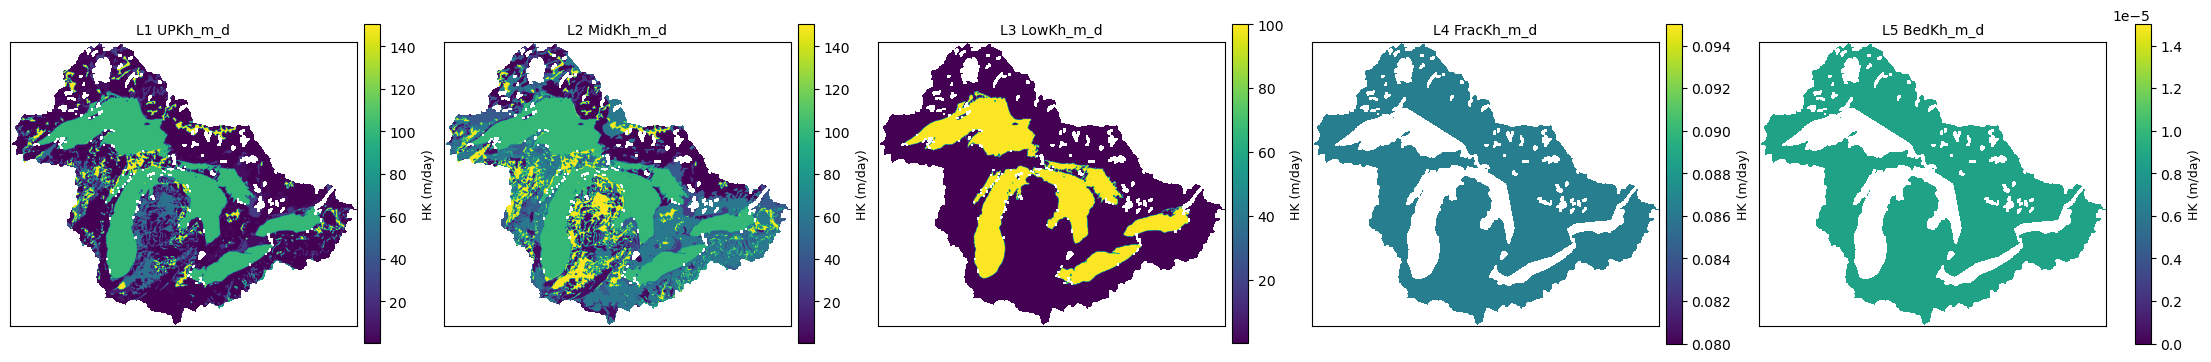

In [12]:
import numpy as np
import rasterio
import matplotlib.pyplot as plt

hk_tif = r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\HK\HK_5band_mday_1000m.tif"

band_names = ["L1 UPKh_m_d","L2 MidKh_m_d","L3 LowKh_m_d","L4 FracKh_m_d","L5 BedKh_m_d"]

# fixed ranges for constant layers (m/day)
FIXED_RANGES = {
    4: (0.080, 0.095),          # around 0.0864
    5: (0.0, 1.5e-5),           # around 8.64e-6
}

PCT_LO, PCT_HI = 2, 98

with rasterio.open(hk_tif) as src:
    nodata = src.nodata
    tr = src.transform
    w, h = src.width, src.height
    xmin, ymax = tr.c, tr.f
    xmax = xmin + tr.a * w
    ymin = ymax + tr.e * h
    extent = (xmin, xmax, ymin, ymax)

    fig, axes = plt.subplots(1, 5, figsize=(22, 4), constrained_layout=True)

    for b, ax in enumerate(axes, start=1):
        arr = src.read(b).astype("float32")
        if nodata is not None:
            arr[arr == nodata] = np.nan

        finite = np.isfinite(arr)
        if not finite.any():
            ax.set_title(band_names[b-1])
            ax.axis("off")
            continue

        if b in FIXED_RANGES:
            vmin, vmax = FIXED_RANGES[b]
        else:
            vmin = np.nanpercentile(arr, PCT_LO)
            vmax = np.nanpercentile(arr, PCT_HI)

        im = ax.imshow(arr, extent=extent, origin="upper", vmin=vmin, vmax=vmax)
        ax.set_title(band_names[b-1], fontsize=10)
        ax.set_xticks([]); ax.set_yticks([])
        cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02)
        cb.set_label("HK (m/day)", fontsize=9)

    plt.show()

#### C) Use bedrock surface elevation to build bottoms (this replaces “bottom from LowHK”)
Your bedrock surface raster (integrated_bedrock_surface_elevation.asc) is the top of bedrock (= bottom of unconsolidated). That should define the bottom of your surficial stack.

modelbottom= bedrock_surface−(fractured thickness+bedrock thickness)

In [6]:
import os
import arcpy
from arcpy.sa import Raster, ExtractByMask

arcpy.CheckOutExtension("Spatial")
arcpy.env.overwriteOutput = True

# --- inputs ---
asc_bedrock = r"S:\Data\Other_Data\Xu_2021\Data\01_Bedrock_Topography\integrated_bedrock_surface_elevation.asc"
template_raster = r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\GRID_3174\template_1000m_epsg3174.tif"
boundary_shp = r"S:\Projects\Active\GLB_LHM\LHM_inputs\Boundary\extendedBdry_jan26_adk.shp"

# --- choose thicknesses (meters) ---
FRAC_THICK_M = 50.0
BEDROCK_THICK_M = 500.0
TOTAL_THICK_M = FRAC_THICK_M + BEDROCK_THICK_M

out_dir = r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\Bottom"
os.makedirs(out_dir, exist_ok=True)

bedrock_raw = os.path.join(out_dir, "bedrock_surface_raw.tif")
bedrock_aln = os.path.join(out_dir, "bedrock_surface_aligned.tif")
modelbottom = os.path.join(out_dir, "modelbottom.tif")

# align output grid to the model grid
arcpy.env.snapRaster = template_raster
arcpy.env.cellSize = template_raster
arcpy.env.extent = template_raster
arcpy.env.outputCoordinateSystem = arcpy.Describe(template_raster).spatialReference

# ASCII -> Raster
if arcpy.Exists(bedrock_raw):
    arcpy.management.Delete(bedrock_raw)
arcpy.conversion.ASCIIToRaster(asc_bedrock, bedrock_raw, "FLOAT")

# Project/resample to template grid (bedrock topo is UTM 17N NAD83 per metadata)
if arcpy.Exists(bedrock_aln):
    arcpy.management.Delete(bedrock_aln)
arcpy.management.ProjectRaster(
    in_raster=bedrock_raw,
    out_raster=bedrock_aln,
    out_coor_system=arcpy.Describe(template_raster).spatialReference,
    resampling_type="BILINEAR",
    cell_size=arcpy.Describe(template_raster).meanCellWidth,
    in_coor_system=arcpy.SpatialReference(26917)
)

# Clip/mask to boundary
bed_clip = ExtractByMask(Raster(bedrock_aln), boundary_shp)

# Model bottom = bedrock surface - (fractured+bedrock thickness)
if arcpy.Exists(modelbottom):
    arcpy.management.Delete(modelbottom)
(bed_clip - TOTAL_THICK_M).save(modelbottom)

arcpy.management.CalculateStatistics(modelbottom)

print("✅ modelbottom written:", modelbottom)
print("   TOTAL_THICK_M =", TOTAL_THICK_M, "m")

✅ modelbottom written: D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\Bottom\modelbottom.tif
   TOTAL_THICK_M = 550.0 m


# Convert Ibound to tif

In [ ]:
Ibound = r'S:\Projects\Active\GLB_LHM\LHM_inputs\Boundary\extendedBdry_jan26_adk.shp'
Ibound_ras = r'D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\Ibound\extendedBdry_jan26_adk.tif'
dem = r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\DEM\DEM_merged_3174_30m.tif"

import arcpy
arcpy.env.overwriteOutput = True
arcpy.env.snapRaster = dem
arcpy.env.cellSize = dem

arcpy.conversion.PolygonToRaster(
    in_features=Ibound,
    value_field="FID",
    out_rasterdataset=Ibound_ras,
    cell_assignment="MAXIMUM_AREA",
    priority_field="NONE",
    cellsize=dem
)
print("✅ Rasterized Ibound to:", Ibound_ras)

# Create a recharge raster 

## Recharge NetCDF → MODFLOW-ready recharge rasters (m/day) — what this cell does

This workflow converts your **annual recharge NetCDF** (`NOAH_annual_recharge_2000_2024_1.nc`, variable `Qsb`) into **year-by-year GeoTIFF rasters** that are:

- **Projected to EPSG:3174** (NAD_1983_Great_Lakes_Basin_Albers)
- **Clipped to your model boundary** (`extendedBdry_jan26_adk.shp`)
- **Resampled to your MODFLOW grid cell size** (e.g., `CELL_SIZE_OUT = 5000 m`)
- **Converted to recharge units in m/day** (so it can be used directly in MODFLOW 6 RCH/UZF workflows)

### Why this approach (and why not “one multiband raster”)?

ArcGIS can be unstable when exporting **NetCDF raster layers** directly to multiband TIFFs or using `in_memory` for intermediate rasters.  
This script avoids common ArcGIS failures (e.g., `ERROR 999999`, missing CRS, all-zero outputs) by:

- **Never calling `CopyRaster()` on a NetCDF raster layer**
- Writing intermediates to a **scratch FileGDB** (more reliable than `in_memory`)
- Only applying **extent/cellsize environments after projection**
- Writing final outputs with **ProjectRaster → GeoTIFF**, which reliably embeds CRS metadata

### Key steps in the script

1. **Sanity check NetCDF values (xarray)**
   - Confirms the NetCDF actually has non-zero recharge values for the first year.
   - Example: `max ≈ 252` indicates the data are present.

2. **Prepare boundary in EPSG:3174**
   - Ensures the clipping boundary is correctly in the target projection.
   - (A wrong “defined projection” on the boundary is a common reason for all-zero outputs.)

3. **Loop over years (BY_INDEX)**
   For each year:
   - `MakeNetCDFRasterLayer` extracts the year slice from the NetCDF
   - `ProjectRaster` projects the slice from **EPSG:4326 → EPSG:3174**
   - `ExtractByMask` clips to the model boundary
   - Converts units to **m/day**
   - Saves a GeoTIFF `rech_mday_<year>.tif`

4. **Unit conversion to m/day**
   The conversion is controlled by `CONV_MODE`:

   - `mm_per_year`:  
     \[
     m/day = \frac{mm/yr}{1000 \cdot 365.25}
     \]
   - `kg_m2_s` (common for flux outputs):  
     \[
     m/day = \frac{kg/m^2/s \cdot 86400}{1000}
     \]
   - `m_per_s`:  
     \[
     m/day = m/s \cdot 86400
     \]

   If your `Qsb` looks like an annual total (max ~ 100–500), `mm_per_year` is usually correct.
   If values are very small (e.g., 1e-6), it may be a flux and `kg_m2_s` or `m_per_s` may be correct.

### Outputs

- A folder like:
  `.../Recharge_for_MF6/rech_mday_5000m/`
- Contains yearly rasters:
  - `rech_mday_2000.tif`
  - `rech_mday_2001.tif`
  - …
  - `rech_mday_2024.tif`

These can be used as **stress-period recharge inputs** in MODFLOW 6 after you map each year to the correct stress period.

### Quick validation checks (recommended)

After generating rasters, check:

- The CRS is EPSG:3174 (not “Unknown”)
- The raster extent overlaps the model boundary
- `MAXIMUM` is non-zero for at least one year (and values are reasonable after conversion)

If `raw MAX` becomes `0` immediately after masking, it usually means:
- boundary CRS is wrong OR
- projection transformation is wrong OR
- the netCDF slice did not project correctly

This is why the script prints `raw MAX` and `m/day MAX` each year.


In [ ]:
import arcpy
import os
import numpy as np
import xarray as xr
from arcpy.sa import ExtractByMask, Con, IsNull, Raster

arcpy.CheckOutExtension("Spatial")
arcpy.env.overwriteOutput = True
arcpy.env.parallelProcessingFactor = "100%"
arcpy.env.addOutputsToMap = False

# ============================================================
# INPUTS
# ============================================================
nc_file   = r"D:\Users\abolmaal\modelling\Projects\GreatLakes\outputs\NOAH-VIC_annual_recharge_2000_2025.nc"
varname   = "Qsb"
x_dim     = "lon"
y_dim     = "lat"
t_dim     = "year"

boundary_shp = r"S:\Projects\Active\GLB_LHM\LHM_inputs\Boundary\extendedBdry_jan26_adk.shp"

out_dir = r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\Recharge"
os.makedirs(out_dir, exist_ok=True)

CELL_SIZE_OUT = 1000  # meters (match your MF6 grid)

# ============================================================
# UNIT CONVERSION TO m/day  (choose correct mode)
# ============================================================
# Your NetCDF max ~252 strongly suggests mm/year:
# m/day = (mm/yr)/1000/365.25
CONV_MODE = "mm_per_year"   # alternatives: "kg_m2_s", "m_per_s", "m_per_day"

def to_mday(r):
    if CONV_MODE == "mm_per_year":
        return r / 365.2595636
    if CONV_MODE == "kg_m2_s":
        return (r * 86400.0) / 1000.0
    if CONV_MODE == "m_per_s":
        return r * 86400.0
    if CONV_MODE == "m_per_day":
        return r
    raise ValueError("Bad CONV_MODE")

# ============================================================
# SPATIAL REFERENCES
# ============================================================
sr_wgs84 = arcpy.SpatialReference(4326)
sr_3174  = arcpy.SpatialReference(3174)

tx_list = arcpy.ListTransformations(sr_wgs84, sr_3174)
geo_tx = tx_list[0] if tx_list else ""
print("Geographic transformation:", geo_tx if geo_tx else "(none listed)")

# ============================================================
# SCRATCH WORKSPACE (avoid in_memory for NetCDF workflows)
# ============================================================
scratch_gdb = os.path.join(out_dir, "rech_scratch.gdb")
if not arcpy.Exists(scratch_gdb):
    arcpy.management.CreateFileGDB(out_dir, os.path.basename(scratch_gdb))

arcpy.env.workspace = scratch_gdb
arcpy.env.scratchWorkspace = scratch_gdb

# ============================================================
# 0) NetCDF sanity check
# ============================================================
ds = xr.open_dataset(nc_file)
years = [int(y) for y in ds[t_dim].values]
a0 = ds[varname].isel({t_dim: 0}).values
print(f"NetCDF check (year={years[0]}): min/max = {float(np.nanmin(a0))} / {float(np.nanmax(a0))}")

# ============================================================
# 1) Boundary prep (make sure it is EPSG:3174)
# ============================================================
print("\n1/5 Boundary prep...")
boundary_3174 = os.path.join(out_dir, "boundary_3174.shp")
if arcpy.Exists(boundary_3174):
    arcpy.management.Delete(boundary_3174)

b_sr = arcpy.Describe(boundary_shp).spatialReference
if b_sr and b_sr.factoryCode == 3174:
    arcpy.management.CopyFeatures(boundary_shp, boundary_3174)
else:
    # project if not already 3174
    arcpy.management.Project(boundary_shp, boundary_3174, sr_3174)

bd = arcpy.Describe(boundary_3174)
print("  boundary_3174 SR:", bd.spatialReference.name, bd.spatialReference.factoryCode)
print("  boundary_3174 extent:", (bd.extent.XMin, bd.extent.YMin, bd.extent.XMax, bd.extent.YMax))

# ============================================================
# 2) Output folder for yearly rasters
# ============================================================
print("\n2/5 Output folder...")
year_dir = os.path.join(out_dir, f"rech_mday_{CELL_SIZE_OUT}m")
os.makedirs(year_dir, exist_ok=True)
print("  ✅", year_dir)

# ============================================================
# Helper: safe gp messages
# ============================================================
def gp_fail(tag):
    print(f"\n❌ FAILED at: {tag}")
    print(arcpy.GetMessages(2))
    raise arcpy.ExecuteError(arcpy.GetMessages(2))

def raster_max(path):
    return float(arcpy.management.GetRasterProperties(path, "MAXIMUM").getOutput(0))

# ============================================================
# 3) Loop years (BY_INDEX) -> ProjectRaster -> Mask -> Convert -> Write GeoTIFF
# ============================================================
print("\n3/5 Build yearly rasters (m/day)...")

for idx, y in enumerate(years, start=1):
    print(f"\n  Year {y} (index {idx})...")

    # ---- IMPORTANT: clear extent while projecting from WGS84 NetCDF ----
    arcpy.ClearEnvironment("extent")
    arcpy.ClearEnvironment("cellSize")
    arcpy.ClearEnvironment("snapRaster")
    arcpy.env.outputCoordinateSystem = None

    lyr_name = f"Qsb_{y}_lyr"
    try:
        res = arcpy.md.MakeNetCDFRasterLayer(
            in_netCDF_file=nc_file,
            variable=varname,
            x_dimension=x_dim,
            y_dimension=y_dim,
            out_raster_layer=lyr_name,
            band_dimension="",
            dimension_values=f"{t_dim} {idx}",
            value_selection_method="BY_INDEX"
        )
        nc_lyr = res.getOutput(0)  # robust handle
    except arcpy.ExecuteError:
        gp_fail("MakeNetCDFRasterLayer")

    # Project directly from NetCDF layer (NO CopyRaster)
    tmp_3174 = os.path.join(scratch_gdb, f"qsb_{y}_3174")
    if arcpy.Exists(tmp_3174):
        arcpy.management.Delete(tmp_3174)

    try:
        arcpy.management.ProjectRaster(
            in_raster=nc_lyr,
            out_raster=tmp_3174,
            out_coor_system=sr_3174,
            resampling_type="BILINEAR",
            cell_size=CELL_SIZE_OUT,
            geographic_transform=geo_tx,
            in_coor_system=sr_wgs84  # force input CRS
        )
    except arcpy.ExecuteError:
        gp_fail("ProjectRaster (NetCDF->3174)")

    # Now we can set processing env to boundary (same CRS)
    arcpy.env.outputCoordinateSystem = sr_3174
    arcpy.env.extent = boundary_3174
    arcpy.env.cellSize = CELL_SIZE_OUT

    # Mask to boundary
    try:
        masked = ExtractByMask(Raster(tmp_3174), boundary_3174)
    except arcpy.ExecuteError:
        gp_fail("ExtractByMask")

    # Save raw masked (debug + ensures stats exist)
    raw_tif = os.path.join(year_dir, f"Qsb_raw_{y}.tif")
    if arcpy.Exists(raw_tif):
        arcpy.management.Delete(raw_tif)

    try:
        masked.save(raw_tif)
        arcpy.management.DefineProjection(raw_tif, sr_3174)
        arcpy.management.CalculateStatistics(raw_tif)
    except arcpy.ExecuteError:
        gp_fail("Save raw masked TIFF")

    mx_raw = raster_max(raw_tif)
    print("    raw MAX:", mx_raw)

    if idx == 1 and mx_raw == 0.0:
        # If this happens, it means overlap/projection is still wrong
        r_ext = arcpy.Describe(raw_tif).extent
        b_ext = arcpy.Describe(boundary_3174).extent
        raise RuntimeError(
            "Year 2000 raw MAX is 0 after masking.\n"
            f"raw extent: {(r_ext.XMin,r_ext.YMin,r_ext.XMax,r_ext.YMax)}\n"
            f"bdry extent: {(b_ext.XMin,b_ext.YMin,b_ext.XMax,b_ext.YMax)}\n"
            "This indicates the projected raster and boundary do not overlap."
        )

    # Convert NoData->0 then to m/day
    masked0 = Con(IsNull(Raster(raw_tif)), 0, Raster(raw_tif))
    r_mday = to_mday(masked0)
    r_mday = Con(r_mday < 0, 0, r_mday)

    # Save m/day to scratch first (keeps CRS), then ProjectRaster -> GeoTIFF (embeds CRS tags)
    mday_tmp = os.path.join(scratch_gdb, f"rech_mday_{y}")
    if arcpy.Exists(mday_tmp):
        arcpy.management.Delete(mday_tmp)

    try:
        r_mday.save(mday_tmp)
        arcpy.management.DefineProjection(mday_tmp, sr_3174)
    except arcpy.ExecuteError:
        gp_fail("Save m/day (scratch)")

    out_tif = os.path.join(year_dir, f"rech_mday_{y}.tif")
    if arcpy.Exists(out_tif):
        arcpy.management.Delete(out_tif)

    try:
        arcpy.management.ProjectRaster(
            in_raster=mday_tmp,
            out_raster=out_tif,
            out_coor_system=sr_3174,
            resampling_type="NEAREST",
            cell_size=CELL_SIZE_OUT,
            in_coor_system=sr_3174
        )
        arcpy.management.CalculateStatistics(out_tif)
    except arcpy.ExecuteError:
        gp_fail("ProjectRaster (mday->GeoTIFF)")

    print("    m/day MAX:", raster_max(out_tif))

print("\nDONE ✅")
print("Yearly recharge rasters (m/day):", year_dir)
print("Conversion mode:", CONV_MODE)


# Function to compute NOAH and VIC average

In [ ]:
from pathlib import Path
import re
import xarray as xr
import numpy as np

def write_monthly_blend_nc_by_year(
    noah_root: Path,
    vic_root: Path,
    out_root: Path,
    years=range(2000, 2026),
    var_name="Qsb",
    scale_factor=0.75,
    out_var_name=None,          # default keeps same var name (Qsb) for easy downstream use
    file_glob="*.nc*",
    filename_prefix="BLEND",    # output file prefix
):
    """
    Create monthly blended NetCDFs in year folders:

      out_root/2000/BLEND_Qsb_A200001.nc
      out_root/2000/BLEND_Qsb_A200002.nc
      ...
      out_root/2025/BLEND_Qsb_A202512.nc

    Blend per month:
        blend = 0.7 * (NOAH + VIC)/2

    Matching is done by parsing AYYYYMM from file names (e.g., ...A201908...nc).
    """

    noah_root = Path(noah_root)
    vic_root  = Path(vic_root)
    out_root  = Path(out_root)
    out_root.mkdir(parents=True, exist_ok=True)

    if out_var_name is None:
        out_var_name = var_name  # keep same variable name unless you want Qsb_blend

    # Parse AYYYYMM anywhere in filename
    yyyymm_re = re.compile(r"A(\d{6})")

    def index_files_by_yyyymm(year_dir: Path):
        """Return {yyyymm: Path} for all files in the year directory."""
        out = {}
        for f in sorted(year_dir.glob(file_glob)):
            m = yyyymm_re.search(f.name)
            if not m:
                continue
            yyyymm = m.group(1)
            out[yyyymm] = f
        return out

    wrote = 0

    for yr in years:
        noah_year_dir = noah_root / f"{yr}"
        vic_year_dir  = vic_root  / f"{yr}"
        out_year_dir  = out_root  / f"{yr}"
        out_year_dir.mkdir(parents=True, exist_ok=True)

        if not noah_year_dir.exists():
            print(f"[WARN] Missing NOAH folder: {noah_year_dir}")
            continue
        if not vic_year_dir.exists():
            print(f"[WARN] Missing VIC folder:  {vic_year_dir}")
            continue

        noah_map = index_files_by_yyyymm(noah_year_dir)
        vic_map  = index_files_by_yyyymm(vic_year_dir)

        # process all 12 months explicitly
        months_written = 0
        for m in range(1, 13):
            yyyymm = f"{yr}{m:02d}"

            if yyyymm not in noah_map:
                print(f"[WARN] {yr}-{m:02d}: NOAH missing")
                continue
            if yyyymm not in vic_map:
                print(f"[WARN] {yr}-{m:02d}: VIC missing")
                continue

            f_noah = noah_map[yyyymm]
            f_vic  = vic_map[yyyymm]

            try:
                ds_noah = xr.open_dataset(f_noah, decode_times=True)
                ds_vic  = xr.open_dataset(f_vic,  decode_times=True)

                if var_name not in ds_noah.variables:
                    raise KeyError(f"{f_noah.name}: variable '{var_name}' not found")
                if var_name not in ds_vic.variables:
                    raise KeyError(f"{f_vic.name}: variable '{var_name}' not found")

                da_noah = ds_noah[var_name]
                da_vic  = ds_vic[var_name]

                # Align grids/coords safely (inner keeps common coords if tiny differences exist)
                da_noah, da_vic = xr.align(da_noah, da_vic, join="inner")

                # Blend
                da_blend = ((da_noah + da_vic) / 2.0) * float(scale_factor)

                # Ensure there is a time dimension (NLDAS monthly usually has time=1)
                if "time" not in da_blend.dims:
                    # create a synthetic time coordinate: first day of that month
                    t = np.datetime64(f"{yr}-{m:02d}-01")
                    da_blend = da_blend.expand_dims(time=[t])

                # Build output dataset
                da_blend.name = out_var_name
                ds_out = da_blend.to_dataset()

                # Metadata
                units = da_noah.attrs.get("units") or ds_noah[var_name].attrs.get("units") or ""
                if units:
                    ds_out[out_var_name].attrs["units"] = units
                ds_out[out_var_name].attrs["blend_method"] = f"(({var_name}_NOAH + {var_name}_VIC)/2) * {scale_factor}"
                ds_out[out_var_name].attrs["source_files"] = f"NOAH={f_noah.name}; VIC={f_vic.name}"

                # Output path in the same year folder structure
                out_nc = out_year_dir / f"{filename_prefix}_{out_var_name}_A{yyyymm}.nc"

                # Compression
                encoding = {out_var_name: {"zlib": True, "complevel": 4}}

                ds_out.to_netcdf(out_nc, encoding=encoding)

                wrote += 1
                months_written += 1
                print(f"✓ wrote {out_nc}")

            except Exception as e:
                print(f"[SKIP] {yr}-{m:02d} -> {e}")

            finally:
                # Close if opened
                try:
                    ds_noah.close()
                except Exception:
                    pass
                try:
                    ds_vic.close()
                except Exception:
                    pass

        if months_written < 12:
            print(f"[INFO] {yr}: wrote {months_written}/12 months (some missing/corrupt)")

    print(f"\nDONE ✅ Total monthly files written: {wrote}")
    print(f"Output root: {out_root}")
    return out_root

In [ ]:
from pathlib import Path

noah_root = Path(r"T:\Data\Climate_Data\Gridded\Downloaded\NLDAS_2_monthly\Noah\NLDAS\NLDAS_NOAH0125_M.2.0")
vic_root  = Path(r"T:\Data\Climate_Data\Gridded\Downloaded\NLDAS_2_monthly\VIC\NLDAS\NLDAS_VIC0125_M.2.0")
out_root     = Path(r"T:\Data\Climate_Data\Gridded\Downloaded\NLDAS_2_monthly\NOAH_VIC_average")

write_monthly_blend_nc_by_year(
    noah_root=noah_root,
    vic_root=vic_root,
    out_root=out_root,
    years=range(2000, 2026),
    var_name="Qsb",
    scale_factor=0.75
)

## Sanity check 

In [ ]:
from pathlib import Path
import re
import xarray as xr
import numpy as np

yyyymm_re = re.compile(r"A(\d{6})")

def index_files_by_yyyymm(year_dir: Path, file_glob="*.nc*"):
    out = {}
    for f in sorted(year_dir.glob(file_glob)):
        m = yyyymm_re.search(f.name)
        if m:
            out[m.group(1)] = f
    return out

def _minmaxmean(a):
    return (float(np.nanmin(a)), float(np.nanmax(a)), float(np.nanmean(a)))

def spot_check_one_month_verbose(
    noah_root: Path,
    vic_root: Path,
    out_root: Path,
    year: int,
    month: int,
    var_name="Qsb",
    out_var_name=None,
    scale_factor=0.7,
    atol=1e-12,
    rtol=1e-6,
):
    if out_var_name is None:
        out_var_name = var_name

    yyyymm = f"{year}{month:02d}"

    noah_map = index_files_by_yyyymm(Path(noah_root) / f"{year}")
    vic_map  = index_files_by_yyyymm(Path(vic_root)  / f"{year}")
    out_map  = index_files_by_yyyymm(Path(out_root)  / f"{year}")

    f_noah = noah_map.get(yyyymm)
    f_vic  = vic_map.get(yyyymm)
    f_out  = out_map.get(yyyymm)

    print("NOAH file:", f_noah)
    print("VIC  file:", f_vic)
    print("OUT  file:", f_out)

    if not (f_noah and f_vic and f_out):
        raise FileNotFoundError("Missing one of NOAH/VIC/OUT files for this month.")

    ds_noah = xr.open_dataset(f_noah)
    ds_vic  = xr.open_dataset(f_vic)
    ds_out  = xr.open_dataset(f_out)

    try:
        da_noah = ds_noah[var_name]
        da_vic  = ds_vic[var_name]
        da_out  = ds_out[out_var_name]

        # Align to compare cell-by-cell
        da_noah, da_vic, da_out = xr.align(da_noah, da_vic, da_out, join="inner")

        expected = ((da_noah + da_vic) / 2.0) * float(scale_factor)

        noah_vals = da_noah.values
        vic_vals  = da_vic.values
        exp_vals  = expected.values
        out_vals  = da_out.values

        nmin, nmax, nmean = _minmaxmean(noah_vals)
        vmin, vmax, vmean = _minmaxmean(vic_vals)
        emin, emax, emean = _minmaxmean(exp_vals)
        omin, omax, omean = _minmaxmean(out_vals)

        print("\n=== VALUE STATS (after alignment) ===")
        print(f"NOAH     min/max/mean: {nmin} / {nmax} / {nmean}")
        print(f"VIC      min/max/mean: {vmin} / {vmax} / {vmean}")
        print(f"EXPECTED min/max/mean: {emin} / {emax} / {emean}   (0.7*(NOAH+VIC)/2)")
        print(f"OUTPUT   min/max/mean: {omin} / {omax} / {omean}   (your saved BLEND file)")

        diff = out_vals - exp_vals
        diff_max_abs  = float(np.nanmax(np.abs(diff)))
        diff_mean_abs = float(np.nanmean(np.abs(diff)))

        denom = np.maximum(np.abs(exp_vals), 1e-30)
        diff_max_rel  = float(np.nanmax(np.abs(diff) / denom))

        print("\n=== CHECK OUTPUT == EXPECTED ===")
        print("diff max_abs :", diff_max_abs)
        print("diff mean_abs:", diff_mean_abs)
        print("diff max_rel :", diff_max_rel)

        ok = np.allclose(out_vals, exp_vals, atol=atol, rtol=rtol, equal_nan=True)
        print("PASS allclose:", ok)

        # Units (helpful)
        print("\n=== UNITS ===")
        print("NOAH units:", ds_noah[var_name].attrs.get("units", ""))
        print("VIC  units:", ds_vic[var_name].attrs.get("units", ""))
        print("OUT  units:", ds_out[out_var_name].attrs.get("units", ""))

        return ok

    finally:
        ds_noah.close()
        ds_vic.close()
        ds_out.close()

In [ ]:
ok = spot_check_one_month_verbose(
    noah_root=Path(r"T:\Data\Climate_Data\Gridded\Downloaded\NLDAS_2_monthly\Noah\NLDAS\NLDAS_NOAH0125_M.2.0"),
    vic_root=Path(r"T:\Data\Climate_Data\Gridded\Downloaded\NLDAS_2_monthly\VIC\NLDAS\NLDAS_VIC0125_M.2.0"),
    out_root=Path(r"T:\Data\Climate_Data\Gridded\Downloaded\NLDAS_2_monthly\NOAH_VIC_average"),
    year=2000,
    month=8,
    var_name="Qsb",
    scale_factor=0.75
)

In [ ]:
import xarray as xr
import numpy as np

def check_one_pixel(f_noah, f_vic, f_out, var="Qsb", scale=0.7, out_var=None):
    if out_var is None:
        out_var = var

    dsN = xr.open_dataset(f_noah)
    dsV = xr.open_dataset(f_vic)
    dsO = xr.open_dataset(f_out)

    daN, daV, daO = xr.align(dsN[var], dsV[var], dsO[out_var], join="inner")

    expected = ((daN + daV) / 2.0) * scale

    # pick the location of the OUTPUT max (so you see why max stats differ)
    vals = daO.values
    idx = np.unravel_index(np.nanargmax(vals), vals.shape)

    n = float(daN.values[idx])
    v = float(daV.values[idx])
    o = float(daO.values[idx])
    e = float(expected.values[idx])

    print("Index of OUTPUT max:", idx)
    print("NOAH @idx:", n)
    print("VIC  @idx:", v)
    print("Expected blend:", 0.7 * (n + v) / 2.0)
    print("Expected (from array):", e)
    print("OUTPUT:", o)
    print("Diff OUTPUT-Expected:", o - e)

    dsN.close(); dsV.close(); dsO.close()

In [ ]:
check_one_pixel(
    f_noah=r"T:\Data\Climate_Data\Gridded\Downloaded\NLDAS_2_monthly\Noah\NLDAS\NLDAS_NOAH0125_M.2.0\2019\NLDAS_NOAH0125_M.A201908.020.nc",
    f_vic =r"T:\Data\Climate_Data\Gridded\Downloaded\NLDAS_2_monthly\VIC\NLDAS\NLDAS_VIC0125_M.2.0\2019\NLDAS_VIC0125_M.A201908.020.nc",
    f_out =r"T:\Data\Climate_Data\Gridded\Downloaded\NLDAS_2_monthly\NOAH_VIC_average\2019\BLEND_Qsb_A201908.nc",
    var="Qsb",
    scale=0.75
)

In [30]:
import xarray as xr
nc_path = r"T:\Data\Climate_Data\Gridded\Downloaded\NLDAS_2_monthly\NOAH_VIC_average\NLDAS\NLDAS_NOAHVIC_M.2.0\2000\BLEND_Qsb_A200001.nc"
ds = xr.open_dataset(nc_path, engine="netcdf4", decode_times=False)
print(ds["Qsb"].attrs)
print(ds.attrs)

{'units': 'kg m-2', 'standard_name': 'Subsurface runoff', 'long_name': 'Subsurface runoff (baseflow)', 'cell_methods': 'time: sum', 'blend_method': '((Qsb_NOAH + Qsb_VIC)/2) * 0.75', 'source_files': 'NOAH=NLDAS_NOAH0125_M.A200001.020.nc; VIC=NLDAS_VIC0125_M.A200001.020.nc'}
{}


In [32]:
da = ds["Qsb"]
print("units:", da.attrs.get("units"))
print("cell_methods:", da.attrs.get("cell_methods"))
print("long_name:", da.attrs.get("long_name"))
print("min/max:", float(np.nanmin(da.values)), float(np.nanmax(da.values)))

units: kg m-2
cell_methods: time: sum
long_name: Subsurface runoff (baseflow)
min/max: -15.622169494628906 347.3969421386719


# Constant Head Boundary
In MODFLOW, a Constant Head Boundary is a type of boundary condition where the hydraulic head is fixed at a specified value throughout the simulation, regardless of the flow into or out of the model domain at that location.

Purpose: Represents locations where groundwater levels are maintained by an external source (e.g., large rivers, lakes, ocean boundaries, or strong pumping/recharge systems).

In [ ]:
import arcpy, os
import numpy as np

arcpy.env.overwriteOutput = True

# --- INPUTS ---
idomain_ras    = r"D:\path\to\idomain_or_ibound.tif"  # active > 0
water_mask_ras = r"D:\path\to\domain_water_mask.tif"  # lakes = -1
out_dir        = r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\CHD"
os.makedirs(out_dir, exist_ok=True)

out_fc = os.path.join(out_dir, "CHD_shoreline_cells.shp")

# --- lake stage (meters) ---
# Use a constant for now. Replace with per-lake or time-varying values later.
LAKE_STAGE_M = 176.0

# -----------------------------
# Read rasters to numpy
# -----------------------------
id_r = arcpy.Raster(idomain_ras)
wm_r = arcpy.Raster(water_mask_ras)

# Alignment check (important)
if (id_r.meanCellWidth != wm_r.meanCellWidth) or (id_r.meanCellHeight != wm_r.meanCellHeight):
    raise RuntimeError("Cellsize mismatch between idomain and water mask.")
if (id_r.extent.XMin != wm_r.extent.XMin) or (id_r.extent.YMax != wm_r.extent.YMax) or \
   (id_r.width != wm_r.width) or (id_r.height != wm_r.height):
    raise RuntimeError("Grid mismatch (extent/shape) between idomain and water mask. They must be aligned.")

id_arr = arcpy.RasterToNumPyArray(id_r, nodata_to_value=0)
wm_arr = arcpy.RasterToNumPyArray(wm_r, nodata_to_value=0)

active = id_arr > 0
lake   = wm_arr == -1

# -----------------------------
# Find active cells adjacent to lake (4-neighbor)
# (no wraparound; uses slicing)
# -----------------------------
adj = np.zeros_like(active, dtype=bool)

# lake north of cell (row-1)
adj[1:,  :] |= active[1:,  :] & lake[:-1, :]
# lake south of cell (row+1)
adj[:-1, :] |= active[:-1, :] & lake[1:,  :]
# lake west of cell (col-1)
adj[:, 1:]   |= active[:, 1:] & lake[:, :-1]
# lake east of cell (col+1)
adj[:, :-1]  |= active[:, :-1] & lake[:, 1:]

rows, cols = np.where(adj)
print("CHD shoreline cells:", len(rows))

# -----------------------------
# Export points shapefile (cell centers)
# -----------------------------
sr = id_r.spatialReference
cellw = float(id_r.meanCellWidth)
cellh = float(id_r.meanCellHeight)
xmin  = float(id_r.extent.XMin)
ymax  = float(id_r.extent.YMax)

if arcpy.Exists(out_fc):
    arcpy.management.Delete(out_fc)

arcpy.management.CreateFeatureclass(out_dir, os.path.basename(out_fc), "POINT", spatial_reference=sr)
arcpy.management.AddField(out_fc, "row", "LONG")
arcpy.management.AddField(out_fc, "col", "LONG")
arcpy.management.AddField(out_fc, "head_m", "DOUBLE")

with arcpy.da.InsertCursor(out_fc, ["SHAPE@XY", "row", "col", "head_m"]) as icur:
    for r, c in zip(rows, cols):
        # RasterToNumPyArray starts at upper-left; row increases downward
        x = xmin + (c + 0.5) * cellw
        y = ymax - (r + 0.5) * cellh
        icur.insertRow(((x, y), int(r), int(c), float(LAKE_STAGE_M)))

print("Wrote:", out_fc)


# Makin Drains

The Drain package is used to simulate head-dependent flux boundaries to simulate the effects of features such as agricultural drains, which remove water from the aquifer. In the Drain package, if the head in the cell falls below a certain threshold, the flux from the model cell to the drain drops to zero.

# Making the streams 

In [ ]:
import os
import arcpy

arcpy.env.overwriteOutput = True

# ----------------------------
# INPUTS
# ----------------------------
nhd_gdb  = r"S:\Data\GIS_Data\Downloaded\NHD\NHD_H_National_GDB.gdb"
boundary = r"S:\Projects\Active\GLB_LHM\LHM_inputs\Boundary\extendedBdry_jan26_adk.shp"
out_dir  = r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\NHD"
os.makedirs(out_dir, exist_ok=True)

# ----------------------------
# OUTPUT + SCRATCH GDBs
# ----------------------------
out_gdb = os.path.join(out_dir, "NHD_streams.gdb")
if not arcpy.Exists(out_gdb):
    arcpy.management.CreateFileGDB(out_dir, os.path.basename(out_gdb))

scratch_gdb = os.path.join(out_dir, "_scratch_nhd.gdb")
if not arcpy.Exists(scratch_gdb):
    arcpy.management.CreateFileGDB(out_dir, os.path.basename(scratch_gdb))

# ----------------------------
# FIND NHDFlowline
# ----------------------------
candidates = [
    os.path.join(nhd_gdb, "Hydrography", "NHDFlowline"),
    os.path.join(nhd_gdb, "NHDFlowline"),
]
flow_fc = next((p for p in candidates if arcpy.Exists(p)), None)
if flow_fc is None:
    raise FileNotFoundError("Could not find NHDFlowline in the GDB. Tried:\n" + "\n".join(candidates))

print("Using flowlines:", flow_fc)

# ----------------------------
# Get StreamRiver code from domain if possible
# (fallback to 460 which is StreamRiver in NHD)
# ----------------------------
def get_streamriver_code(gdb_path, fc_path, field_name="FType", label="StreamRiver", fallback=460):
    # find field (case-insensitive)
    fld = next((f for f in arcpy.ListFields(fc_path) if f.name.lower() == field_name.lower()), None)
    if fld is None:
        raise ValueError(f"Field '{field_name}' not found in {fc_path}")

    dom_name = fld.domain
    if not dom_name:
        return fallback  # may be coded but no domain exposed; use fallback

    for dom in arcpy.da.ListDomains(gdb_path):
        if dom.name == dom_name and hasattr(dom, "codedValues"):
            for code, lab in dom.codedValues.items():
                if str(lab).strip().lower() == label.lower():
                    return code
    return fallback

stream_code = get_streamriver_code(nhd_gdb, flow_fc, "FType", "StreamRiver", fallback=460)
print("StreamRiver code:", stream_code)

# Build SQL where clause based on field type
ftype_field = next((f for f in arcpy.ListFields(flow_fc) if f.name.lower() == "ftype"), None)
if ftype_field is None:
    raise ValueError("FType field not found (unexpected).")

fld_delim = arcpy.AddFieldDelimiters(flow_fc, ftype_field.name)

if ftype_field.type in ("Integer", "SmallInteger", "Double", "Single"):
    where = f"{fld_delim} = {int(stream_code)}"
else:
    where = f"{fld_delim} = 'StreamRiver'"

print("Where clause:", where)

# ----------------------------
# Project boundary to flowlines CRS (for reliable Select By Location)
# ----------------------------
sr_flow = arcpy.Describe(flow_fc).spatialReference
sr_bdry = arcpy.Describe(boundary).spatialReference

boundary_proj = os.path.join(scratch_gdb, "boundary_proj_to_flow")
if sr_bdry and sr_flow and sr_bdry.factoryCode != sr_flow.factoryCode:
    arcpy.management.Project(boundary, boundary_proj, sr_flow)
    boundary_for_select = boundary_proj
    print(f"Projected boundary -> flow SR (EPSG:{sr_flow.factoryCode}) for selection")
else:
    boundary_for_select = boundary

# ----------------------------
# Make StreamRiver layer + select by location
# ----------------------------
lyr = "nhd_streamriver_lyr"
arcpy.management.MakeFeatureLayer(flow_fc, lyr, where)

cnt_all = int(arcpy.management.GetCount(lyr)[0])
print("StreamRiver features (nationwide, before spatial select):", cnt_all)

arcpy.management.SelectLayerByLocation(
    in_layer=lyr,
    overlap_type="INTERSECT",
    select_features=boundary_for_select,
    selection_type="NEW_SELECTION"
)

cnt_sel = int(arcpy.management.GetCount(lyr)[0])
print("Selected StreamRiver features intersecting boundary:", cnt_sel)

if cnt_sel == 0:
    raise RuntimeError(
        "0 features selected. Likely CRS/extent mismatch or boundary not overlapping NHDFlowline. "
        "Check boundary location and projection."
    )

# ----------------------------
# Copy selected features (now guaranteed to exist)
# ----------------------------
temp_sel = os.path.join(scratch_gdb, "NHD_StreamRiver_sel")
arcpy.management.CopyFeatures(lyr, temp_sel)

if not arcpy.Exists(temp_sel):
    raise RuntimeError("CopyFeatures did not create temp_sel (unexpected).")

# ----------------------------
# Project selected streams to boundary CRS (so Clip is clean)
# ----------------------------
temp_sel_proj = os.path.join(scratch_gdb, "NHD_StreamRiver_sel_proj_to_bdry")
use_fc = temp_sel

if sr_bdry and sr_flow and sr_bdry.factoryCode != sr_flow.factoryCode:
    arcpy.management.Project(temp_sel, temp_sel_proj, sr_bdry)
    use_fc = temp_sel_proj
    print(f"Projected selected streams -> boundary SR (EPSG:{sr_bdry.factoryCode})")

# ----------------------------
# Clip to boundary
# ----------------------------
out_fc = os.path.join(out_gdb, "NHDFlowline_StreamRiver_clip")
arcpy.analysis.PairwiseClip(use_fc, boundary, out_fc)  # faster than Clip in many cases

print("DONE ✅")
print("Output:", out_fc)


### Now merge US and Canada's streams 

In [ ]:
import os
import arcpy

arcpy.env.overwriteOutput = True
arcpy.env.parallelProcessingFactor = "0"   # stability

# -----------------------------
# INPUTS
# -----------------------------
nhd_fc = r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\NHD\NHD_streams.gdb\NHDFlowline_StreamRiver_clip"
ohn_fc = r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\NHD\Ontario_Hydro_Network_(OHN)_-_Watercourse.shp"
boundary = r"S:\Projects\Active\GLB_LHM\LHM_inputs\Boundary\extendedBdry_jan26_adk.shp"

out_dir = r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\NHD\_merged_streams_out"
os.makedirs(out_dir, exist_ok=True)

out_gdb = os.path.join(out_dir, "streams_merge_fast.gdb")
if not arcpy.Exists(out_gdb):
    arcpy.management.CreateFileGDB(out_dir, os.path.basename(out_gdb))

# overlap tolerance (meters): how close OHN can be to NHD to be considered duplicate
tol_m = 25  # try 10–50

def _del_if_exists(p):
    if arcpy.Exists(p):
        arcpy.management.Delete(p)

def _pairwise_clip(in_fc, clip_fc, out_fc):
    _del_if_exists(out_fc)
    try:
        arcpy.analysis.PairwiseClip(in_fc, clip_fc, out_fc)
    except Exception:
        arcpy.analysis.Clip(in_fc, clip_fc, out_fc)
    return out_fc

# -----------------------------
# 1) Get target CRS from boundary
# -----------------------------
target_sr = arcpy.Describe(boundary).spatialReference
if target_sr is None:
    raise RuntimeError("Boundary has no spatial reference. Define projection first.")

# -----------------------------
# 2) Ensure OHN is in boundary CRS (project only OHN)
# -----------------------------
ohn_prj = os.path.join(out_gdb, "ohn_prj")
sr_ohn = arcpy.Describe(ohn_fc).spatialReference

if sr_ohn and target_sr and sr_ohn.factoryCode == target_sr.factoryCode:
    ohn_use = ohn_fc
else:
    _del_if_exists(ohn_prj)
    arcpy.management.Project(ohn_fc, ohn_prj, target_sr)
    ohn_use = ohn_prj

# -----------------------------
# 3) Clip OHN to boundary (NHD already clipped, so we keep it as-is)
# -----------------------------
ohn_clip = os.path.join(out_gdb, "ohn_clip_bdry")
_pairwise_clip(ohn_use, boundary, ohn_clip)

# Clean + index (helps speed)
arcpy.management.RepairGeometry(ohn_clip)
try:
    arcpy.management.AddSpatialIndex(ohn_clip)
except Exception:
    pass
try:
    arcpy.management.AddSpatialIndex(nhd_fc)  # harmless; may already exist
except Exception:
    pass

# -----------------------------
# 4) Remove OHN overlaps: drop OHN features within tol_m of NHD
#    (keeps NHD priority)
# -----------------------------
ohn_keep = os.path.join(out_gdb, "ohn_keep_not_near_nhd")
_del_if_exists(ohn_keep)

nhd_lyr = "nhd_lyr"
ohn_lyr = "ohn_lyr"
arcpy.management.MakeFeatureLayer(nhd_fc, nhd_lyr)
arcpy.management.MakeFeatureLayer(ohn_clip, ohn_lyr)

# Select OHN features that are near/overlapping NHD
arcpy.management.SelectLayerByLocation(
    in_layer=ohn_lyr,
    overlap_type="WITHIN_A_DISTANCE",
    select_features=nhd_lyr,
    search_distance=f"{tol_m} Meters",
    selection_type="NEW_SELECTION"
)

# Keep only OHN features NOT selected
arcpy.management.SelectLayerByAttribute(ohn_lyr, "SWITCH_SELECTION")
arcpy.management.CopyFeatures(ohn_lyr, ohn_keep)

# -----------------------------
# 5) Merge final
# -----------------------------
merged_streams = os.path.join(out_gdb, "streams_merged_noOverlap")
_del_if_exists(merged_streams)
arcpy.management.Merge([nhd_fc, ohn_keep], merged_streams)

# Optional: remove exact duplicates (cheap)
try:
    arcpy.management.DeleteIdentical(merged_streams, ["Shape"], xy_tolerance=f"{tol_m} Meters")
except Exception:
    pass

arcpy.management.RepairGeometry(merged_streams)

print("DONE ✅")
print("Final merged streams:", merged_streams)
print("OHN clipped:", ohn_clip)
print("OHN kept (not near NHD):", ohn_keep)

### Add + calculate width in the streams

In [ ]:
import os
import arcpy
import geopandas as gpd

arcpy.env.overwriteOutput = True
arcpy.management.ClearWorkspaceCache()

gdb = r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\NHD\_merged_streams_out\streams_merge_fast.gdb"
arcpy.env.workspace = gdb

in_fc = "streams_merged_noOverlap"   # <-- use the name, not the full path

gdf = gpd.read_file(gdb, layer=in_fc, driver="OpenFileGDB")
print(gdf.head())

In [ ]:
# copy the geodataframe back to a new shapefile (or feature class) with only selected fields
out_dir = r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\NHD"

out_shp = os.path.join(out_dir, "streams_merged_clip_to_bdry.shp")
if arcpy.Exists(out_shp):
    arcpy.management.Delete(out_shp)
gdf.to_file(out_shp, driver="ESRI Shapefile")
print("✅ Exported to shapefile:", out_shp)

In [ ]:
import numpy as np

def width_rule(row):
    # NHD: FCode + GNIS_NAME
    fcode = row.get("FCode", None)
    gnis  = row.get("GNIS_NAME", None)

    if fcode is not None:
        try:
            fcode = int(fcode)
        except:
            fcode = None

        if fcode == 46003:      # ditch/canal
            w = 4.0
        elif fcode == 46000:    # stream/river
            w = 10.0
        else:
            w = 10.0

        if isinstance(gnis, str) and gnis.strip() != "":
            w = max(w, 25.0)
        return w

    # OHN fallback: FLOW_CLASS / WATERCOURS / PERMANENCY
    wc = str(row.get("WATERCOURS", "")).lower()
    cl = str(row.get("FLOW_CLASS", "")).lower()
    perm = str(row.get("PERMANENCY", "")).lower()

    if "river" in wc:
        w = 25.0
    elif "stream" in wc:
        w = 10.0
    elif "primary" in cl:
        w = 10.0
    elif "secondary" in cl:
        w = 6.0
    else:
        w = 5.0

    if perm and (not perm.startswith("perm")):
        w *= 0.7

    return float(np.clip(w, 1.0, 300.0))

gdf["Width_m"] = gdf.apply(width_rule, axis=1)
print(gdf["Width_m"].describe())

In [ ]:
import os, glob
import geopandas as gpd
import numpy as np

shp = r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\NHD\streams_merged_clip_to_bdry.shp"

# --- read shapefile ---
gdf = gpd.read_file(shp)

# --- helper to find fields even if names got truncated ---
cols = list(gdf.columns)
lut = {c.lower(): c for c in cols}

def pick(candidates):
    for c in candidates:
        if c.lower() in lut:
            return lut[c.lower()]
    return None

F_FCODE = pick(["FCode", "FCODE"])
F_GNIS  = pick(["GNIS_NAME", "GNISNAME"])
F_WATER = pick(["WATERCOURS", "WATERCOUR", "WATERCOURSE"])
F_CLASS = pick(["FLOW_CLASS", "FLOWCLAS"])
F_PERM  = pick(["PERMANENCY", "PERMANENC"])

print("Using fields:", F_FCODE, F_GNIS, F_WATER, F_CLASS, F_PERM)

# --- width rule ---
def width_rule(row):
    w = None

    # NHD logic if FCode exists on that feature
    fcode = row.get(F_FCODE) if F_FCODE else None
    gnis  = row.get(F_GNIS)  if F_GNIS  else None

    if fcode is not None and str(fcode) != "":
        try:
            fcode_i = int(fcode)
        except Exception:
            fcode_i = None

        if fcode_i == 46003:      # ditch/canal
            w = 4.0
        elif fcode_i == 46000:    # stream/river
            w = 10.0
        else:
            w = 10.0

        if isinstance(gnis, str) and gnis.strip() != "":
            w = max(w, 25.0)

    # OHN fallback if no FCode
    if w is None:
        wc = str(row.get(F_WATER, "")).lower() if F_WATER else ""
        cl = str(row.get(F_CLASS, "")).lower() if F_CLASS else ""
        pm = str(row.get(F_PERM,  "")).lower() if F_PERM  else ""

        if "river" in wc:
            w = 25.0
        elif "stream" in wc:
            w = 10.0
        elif "primary" in cl:
            w = 10.0
        elif "secondary" in cl:
            w = 6.0
        else:
            w = 5.0

        if pm and (not pm.startswith("perm")):
            w *= 0.7

    return float(np.clip(w, 1.0, 300.0))

# --- add shapefile-safe width field ---
gdf["WIDTH_M"] = gdf.apply(width_rule, axis=1).astype("float64")

# --- OPTIONAL but recommended: keep only a few columns to avoid 2GB DBF ---
keep = ["geometry", "WIDTH_M"]
for f in [F_FCODE, F_GNIS, F_WATER, F_CLASS, F_PERM]:
    if f and f not in keep:
        keep.append(f)

gdf_out = gdf[keep].copy()

# --- delete existing shapefile parts so overwrite is clean ---
base = os.path.splitext(shp)[0]
for p in glob.glob(base + ".*"):
    try:
        os.remove(p)
    except Exception:
        pass

# --- write back to the SAME shapefile path ---
gdf_out.to_file(shp, driver="ESRI Shapefile")
print("✅ Wrote WIDTH_M back to:", shp)
print("Saved columns:", list(gdf_out.columns))

In [ ]:
pathInputDrn       = r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\NHD\streams_merged_clip_to_bdry.shp"


In [ ]:
import arcpy, os

arcpy.env.overwriteOutput = True

in_streams = pathInputDrn
template = r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\GRID_3174\template_5000m_epsg3174.tif"

out_dir = r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\NHD"
os.makedirs(out_dir, exist_ok=True)

gdb = os.path.join(out_dir, "streams_tmp.gdb")
if not arcpy.Exists(gdb):
    arcpy.management.CreateFileGDB(out_dir, "streams_tmp.gdb")

proj_fc = os.path.join(gdb, "streams_3174")
clip_fc = os.path.join(gdb, "streams_3174_clip")

# spatial reference from template
sr = arcpy.Describe(template).spatialReference

# --- Project ---
if arcpy.Exists(proj_fc):
    arcpy.management.Delete(proj_fc)

arcpy.management.Project(in_streams, proj_fc, sr)
print("Projected to:", proj_fc, "exists?", arcpy.Exists(proj_fc))

# --- Build extent polygon feature class in the SAME GDB ---
ext = arcpy.Describe(template).extent
extent_poly = arcpy.Polygon(arcpy.Array([
    arcpy.Point(ext.XMin, ext.YMin),
    arcpy.Point(ext.XMin, ext.YMax),
    arcpy.Point(ext.XMax, ext.YMax),
    arcpy.Point(ext.XMax, ext.YMin),
    arcpy.Point(ext.XMin, ext.YMin),
]), sr)

extent_fc = os.path.join(gdb, "template_extent")
if arcpy.Exists(extent_fc):
    arcpy.management.Delete(extent_fc)
arcpy.management.CopyFeatures(extent_poly, extent_fc)

# --- Clip ---
if arcpy.Exists(clip_fc):
    arcpy.management.Delete(clip_fc)

arcpy.analysis.Clip(proj_fc, extent_fc, clip_fc)
print("Clipped to:", clip_fc, "exists?", arcpy.Exists(clip_fc))

# Optional: export clipped to shapefile (for geopandas)
clip_shp = os.path.join(out_dir, "streams_3174_clip_to_modelgrid.shp")
if arcpy.Exists(clip_shp):
    arcpy.management.Delete(clip_shp)
arcpy.conversion.FeatureClassToFeatureClass(clip_fc, out_dir, "streams_3174_clip_to_modelgrid.shp")

print("✅ clipped shapefile:", clip_shp, "exists?", arcpy.Exists(clip_shp))

# Prep observaation wells Inputs

In [ ]:
import os
import arcpy
from arcpy import sa

arcpy.env.overwriteOutput = True
arcpy.CheckOutExtension("Spatial")

# ----------------------------
# INPUTS
# ----------------------------
Well_path   = r"S:\Data\GIS_Data\Derived\Great_Lakes_Basin\Watersheds\Water_Wells\GLB_water_wells.gdb\GLB_domestic_water_wells"
boundary_p  = r"S:\Projects\Active\GLB_LHM\LHM_inputs\Boundary\extendedBdry_jan26_adk.shp"
dem_tif     = r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\DEM\DEM_merged_3174_30m.tif"
out_dir     = r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\Wells"
os.makedirs(out_dir, exist_ok=True)

# Create an output FileGDB (recommended vs shapefile)
out_gdb = os.path.join(out_dir, "Wells.gdb")
if not arcpy.Exists(out_gdb):
    arcpy.management.CreateFileGDB(out_dir, "Wells.gdb")

# Output names
bdry_well_sr   = os.path.join(out_gdb, "boundary_wellSR")
wells_clip     = os.path.join(out_gdb, "wells_in_boundary")
wells_3174     = os.path.join(out_gdb, "wells_in_boundary_3174")
wells_dem      = os.path.join(out_gdb, "wells_in_boundary_3174_dem")

# ----------------------------
# 1) Get spatial references
# ----------------------------
sr_well = arcpy.Describe(Well_path).spatialReference
sr_dem  = arcpy.Describe(dem_tif).spatialReference

print("Wells SR:", sr_well.name)
print("DEM SR:", sr_dem.name)

# ----------------------------
# 2) Project boundary to wells SR (so clip is correct)
# ----------------------------
# (If it's already in that SR, Project will still work.)
arcpy.management.Project(boundary_p, bdry_well_sr, sr_well)

# ----------------------------
# 3) Clip wells to boundary (fast)
# ----------------------------
# PairwiseClip is usually faster/safer for big data
arcpy.analysis.PairwiseClip(Well_path, bdry_well_sr, wells_clip)
print("Wells clipped:", int(arcpy.management.GetCount(wells_clip)[0]))

# ----------------------------
# 4) Project clipped wells to DEM SR (EPSG:3174 likely)
# ----------------------------
arcpy.management.Project(wells_clip, wells_3174, sr_dem)
print("Wells projected to DEM SR:", int(arcpy.management.GetCount(wells_3174)[0]))

# ----------------------------
# 5) Sample DEM to assign elevation
# ----------------------------
# Creates a NEW point FC with a raster value field (usually "RASTERVALU")
# You can set "NONE" or "BILINEAR" for interpolation. For DEM, BILINEAR is common.
sa.ExtractValuesToPoints(
    in_point_features=wells_3174,
    in_raster=dem_tif,
    out_point_features=wells_dem,
    interpolate_values="BILINEAR",
    add_attributes="VALUE_ONLY"
)
print("Wells with DEM elevation:", int(arcpy.management.GetCount(wells_dem)[0]))

# Rename RASTERVALU -> DEM_ELEV_M (optional but nice)
fields = [f.name for f in arcpy.ListFields(wells_dem)]
if "RASTERVALU" in fields and "DEM_ELEV_M" not in fields:
    arcpy.management.AlterField(wells_dem, "RASTERVALU", new_field_name="DEM_ELEV_M", new_field_alias="DEM_ELEV_M")

# ----------------------------
# 6) (Optional) Remove wells where DEM was NoData
# ----------------------------
# DEM_ELEV_M will be None for NoData locations
tmp_layer = "wells_dem_lyr"
arcpy.management.MakeFeatureLayer(wells_dem, tmp_layer)
arcpy.management.SelectLayerByAttribute(tmp_layer, "NEW_SELECTION", "DEM_ELEV_M IS NULL")
n_nodata = int(arcpy.management.GetCount(tmp_layer)[0])
if n_nodata > 0:
    arcpy.management.SelectLayerByAttribute(tmp_layer, "SWITCH_SELECTION")
    cleaned = os.path.join(out_gdb, "wells_in_boundary_3174_dem_clean")
    arcpy.management.CopyFeatures(tmp_layer, cleaned)
    print("Removed NoData wells:", n_nodata)
    print("CLEAN output:", cleaned)
else:
    cleaned = wells_dem
    print("No NoData wells found.")

print("\nDONE.")
print("Final wells feature class:", cleaned)
print("Saved in:", out_gdb)